In [1]:
import sys 

sys.path.append("../")

In [2]:
import time 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from src import ASTPruner, ASTTreeOperator, SqlglotOperator, OntologyOperator, TreeNode

# measures we need to gather in the evaluation process 
- overall time taken for a single query 
- number of nodes in the ast tree
- number of reference nodes in the ast tree 
- policies that used in the query update process 
- rules that used in the query update process 

In [3]:
class Evaluator:
    def __init__(self, ontology_path, agent_id, output_path):
        self.onto = OntologyOperator(ontology_path)
        self.agent_id = agent_id
        self.output_path = output_path

    def compare_trees(self, root1: 'TreeNode', root2: 'TreeNode') -> bool:
        """
        Compares two ASTs for structural and content similarity.
        """

        def _nodes_are_similar(node1: 'TreeNode', node2: 'TreeNode') -> bool:
            """Helper to compare two individual nodes based on the specified rules."""
            if not node1 or not node2:
                return False # Should not happen if called from the main recursion

            # Rule 1: General similarity check for kind and name.
            if node1.kind != node2.kind or node1.name != node2.name:
                return False

            # Rule 2: Special check for TableRef nodes.
            if node1.name == "TableRef":
                id1 = getattr(node1, 'table_reference_id', None)
                id2 = getattr(node2, 'table_reference_id', None)
                if id1 != id2:
                    return False

            # Rule 3: Special check for ColumnRef nodes.
            if node1.name == "ColumnRef":
                id1 = getattr(node1, 'column_reference_id', None)
                id2 = getattr(node2, 'column_reference_id', None)
                if id1 != id2:
                    return False
            
            # If all checks pass, the nodes are similar.
            return True

        def _are_trees_similar_recursive(node1: 'TreeNode', node2: 'TreeNode') -> bool:
            """The main recursive engine for comparing nodes and their subtrees."""
            # Base case: If one node is None and the other isn't, they're not similar.
            if (node1 is None) != (node2 is None):
                return False
            # Base case: If both are None, they are similar.
            if node1 is None and node2 is None:
                return True

            # 1. Compare the current nodes themselves.
            if not _nodes_are_similar(node1, node2):
                return False
            
            # 2. Check if they have the same number of children.
            if len(node1.children) != len(node2.children):
                return False
                
            # 3. Compare the children as unordered sets.
            # This logic ensures that for every child in node1, a matching subtree
            # exists in node2.
            children2_copy = list(node2.children)
            
            for child1 in node1.children:
                found_match = False
                match_index = -1
                for i, child2 in enumerate(children2_copy):
                    # Recursive call: check if the entire subtrees are similar.
                    if _are_trees_similar_recursive(child1, child2):
                        found_match = True
                        match_index = i
                        break # Found a match, move to the next child1.
                
                if not found_match:
                    # If no matching subtree was found for child1, the trees differ.
                    return False
                
                # Remove the matched child so it can't be matched again.
                children2_copy.pop(match_index)
                
            # If all children in node1 found a unique match in node2, the subtrees are similar.
            return True

        # Start the comparison from the root nodes.
        return _are_trees_similar_recursive(root1, root2)
    
    def _string_martching(self, str1, str2):
        """
        A simple string matching function to compare two strings.
        """
        return str1.rstrip(";").strip() == str2.rstrip(";").strip()
    
    def _get_reasoning_stats(self):
        column_ref_instances = self.onto.get_column_ref_instances()
        table_ref_instances = self.onto.get_table_ref_instances()

        # get status 
        policy_set = set()
        rule_set = set()
        for inst in column_ref_instances.values():
            policy_set.add(inst.get('Policy', None))
            rule_set.add(inst.get('Rule', None))
        for inst in table_ref_instances.values():
            policy_set.add(inst.get('Policy', None))
            rule_set.add(inst.get('Rule', None))

        # remove None values
        policy_set.discard(None)
        rule_set.discard(None)
        # convert to list
        # policy_set = list(policy_set)
        # rule_set = list(rule_set)
        return policy_set, rule_set

    def _run_query(self, test_query, expected_query):
        start_counter = time.perf_counter()
        # test query update first run 
        test_sql_op = SqlglotOperator(test_query)
        test_tree_op = ASTTreeOperator(test_sql_op)
        self.onto.instantiate_ontology(test_tree_op, self.agent_id)
        self.onto.reason_and_save(self.output_path, save=False)
        pruner = ASTPruner(self.onto)
        pruner.prune()
        output_query = test_sql_op.to_sql(pretty=False)
        print(f"Output query: {output_query}")

        end_counter = time.perf_counter()
        runtime = end_counter - start_counter

        # get run statistics
        ast_stats = self.onto.get_statistics()
        policy_set, rule_set = self._get_reasoning_stats()

        # expected query run 
        print(f"Expected query: {expected_query}")
        if expected_query:
            expected_sql_op = SqlglotOperator(expected_query)
            expected_tree_op = ASTTreeOperator(expected_sql_op)
            self.onto.instantiate_ontology(expected_tree_op, self.agent_id)
        self.onto.cleanup()

        # test query second run 
        if output_query:
            rerun_sql_op = SqlglotOperator(output_query)
            rerun_tree_op = ASTTreeOperator(rerun_sql_op)
            self.onto.instantiate_ontology(rerun_tree_op, self.agent_id)
            self.onto.reason_and_save(self.output_path, save=False)
            pruner = ASTPruner(self.onto)
            pruner.prune()
            rerun_output_query = rerun_sql_op.to_sql(pretty=False)
            self.onto.cleanup()
            
            string_matching = True
        else:
            rerun_output_query = None
            rerun_tree_op = None
            string_matching = None
                    
        if not expected_query:
            if not output_query:
                comparison_result = True
                string_matching = None
            else:
                comparison_result = False
                string_matching = self._string_martching(output_query, rerun_output_query)
        else:
            if output_query:
                string_matching = self._string_martching(output_query, rerun_output_query)
                comparison_result = self.compare_trees(expected_tree_op.root, rerun_tree_op.root)
            else:
                comparison_result = False
                string_matching = None

        
        result_dict = {
            "runtime": runtime,
            "output_query": output_query,
            "rerun_output_query": rerun_output_query,
            "policy_set": policy_set,
            "rule_set": rule_set,
            "update_matching": comparison_result,
            "rerun_matching": string_matching
        }
        result_dict.update(ast_stats)
        return result_dict

    def analyze_query(self, test_query, expected_query, expected_policy_set=None, expected_rule_set=None    ):
        """
        Analyzes the test query against the expected query.
        Returns a dictionary with runtime, policy set, rule set,
        and whether the queries match.
        """
        result_dict = self._run_query(test_query, expected_query)

        # Check if the expected policy set and rule set match the actual ones
        if expected_policy_set is not None:
            result_dict['policy_set_match'] = set(expected_policy_set) == set(result_dict['policy_set'])

        if expected_rule_set is not None:
            result_dict['rule_set_match'] = set(expected_rule_set) == set(result_dict['rule_set'])

        return result_dict
    
    
    def evaluate(self, test_data_path):
        test_df = pd.read_csv(test_data_path).replace({np.nan: None})
        print(test_df.shape)
        # print(test_df.head())
        for row in test_df.itertuples():
            # if row.Index < 45:
            #     continue 

            # if row.Index > 70:
            #     break
            
            print(f"Processing row {row.Index}: {row.input_query} ")
            try:
                result = self.analyze_query(
                    row.input_query, 
                    row.expected_query, 
                    expected_policy_set=row.related_policies, 
                    expected_rule_set=row.related_rules
                )
            except Exception as e:
                result = None
            # Add the result to the DataFrame

            if result:
                for key, value in result.items():
                    if key == 'policy_set' or key == 'rule_set':
                        # Convert set to a sorted list for consistent output
                        value = sorted(value) if value else []
                        # stringify the list for CSV compatibility
                        value = ', '.join(value)
                    test_df.at[row.Index, key] = value

        return test_df


In [4]:
evaluator = Evaluator(ontology_path="../ontology_file/aputv5e.rdf", agent_id="a0012", output_path="")
result_df = evaluator.evaluate(test_data_path="../data/sample_data_mini.csv")
result_df.to_csv("../data/result_mini1.csv", index=False)

(48, 7)
Processing row 0: INSERT INTO "Loan" (loan_id, account_id, amount) VALUES ('l123', 'a456', 5000); 
--> Instantiating ontology individuals...
INSERT INTO "Loan" (loan_id, account_id, amount) VALUES ('l123', 'a456', 5000)
    - Instantiated 1 TableRefs and 0 ColumnRefs.
--> Running reasoner and saving ontology...


* Owlready2 * Running Pellet...
    java -Xmx2000M -cp c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\jena-arq-2.10.0.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\jena-core-2.10.0.jar;c:\Use

* Owlready * Adding relation aputv5e.n86a7af hasParentNode aputv5e.s40e8bc
* Owlready * Adding relation aputv5e.n86a7af hasParentNode aputv5e.nce480c
* Owlready * Adding relation aputv5e.n86a7af hasParentNode aputv5e.n409709
* Owlready * Adding relation aputv5e.n409709 hasParentNode aputv5e.s40e8bc
* Owlready * Adding relation aputv5e.n409709 immediateParentNode aputv5e.s40e8bc
* Owlready * Adding relation aputv5e.n409709 hasChildNode aputv5e.n3f5255
* Owlready * Adding relation aputv5e.n409709 hasChildNode aputv5e.n3b4981
* Owlready * Adding relation aputv5e.n409709 hasChildNode aputv5e.nce480c
* Owlready * Adding relation aputv5e.n409709 hasChildNode aputv5e.n86a7af
* Owlready * Adding relation aputv5e.n409709 immediateChildNode aputv5e.nce480c
* Owlready * Adding relation aputv5e.n213fc8 hasParentNode aputv5e.ncf103a
* Owlready * Adding relation aputv5e.n213fc8 hasParentNode aputv5e.s40e8bc
* Owlready * Adding relation aputv5e.n213fc8 hasParentNode aputv5e.n40e8bc
* Owlready * Addin

* Owlready2 * Pellet took 2.089599132537842 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Running Pellet...
    java -Xmx2000M -cp c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\

--- Starting AST Pruning Process ---
Query before pruning: INSERT INTO "Loan" (loan_id, account_id, amount) VALUES ('l123', 'a456', 5000)
--> Stage 1: Pruning based on table statuses...
--> Stage 2: Pruning based on column statuses...
     - No violated columns found.
Output query: INSERT INTO "Loan" (loan_id, account_id, amount) VALUES ('l123', 'a456', 5000)
Expected query: None
--> Cleanup: Attempting to delete 9 instances...
    - Deleted instance: aputv5e.s40e8bc
    - Deleted instance: aputv5e.n40e8bc
    - Deleted instance: aputv5e.ncf103a
    - Deleted instance: aputv5e.n213fc8
    - Deleted instance: aputv5e.n409709
    - Deleted instance: aputv5e.nce480c
    - Deleted instance: aputv5e.n86a7af
    - Deleted instance: aputv5e.n3b4981
    - Deleted instance: aputv5e.n3f5255
--> Cleanup complete. Successfully deleted 9 instances.
--> Instantiating ontology individuals...
INSERT INTO "Loan" (loan_id, account_id, amount) VALUES ('l123', 'a456', 5000)
    - Instantiated 1 TableRefs 

...

* Owlready2 * Pellet took 4.000071287155151 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)


--- Starting AST Pruning Process ---
Query before pruning: SELECT status, COUNT(*) FROM Loan GROUP BY status
--> Stage 1: Pruning based on table statuses...
--> Stage 2: Pruning based on column statuses...
     - No violated columns found.
Output query: SELECT status, COUNT(*) FROM Loan GROUP BY status
Expected query: SELECT status, COUNT(*) FROM Loan GROUP BY status;
--> Instantiating ontology individuals...
SELECT status, COUNT(*) FROM Loan GROUP BY status
    - Instantiated 1 TableRefs and 2 ColumnRefs.
--> Cleanup: Attempting to delete 9 instances...
    - Deleted instance: aputv5e.s612bd5
    - Deleted instance: aputv5e.n612bd5
    - Deleted instance: aputv5e.n3f9605
    - Deleted instance: aputv5e.n826134
    - Deleted instance: aputv5e.n95973f
    - Deleted instance: aputv5e.nb34bc6
    - Deleted instance: aputv5e.nc5256c
    - Deleted instance: aputv5e.n7dab6b
    - Deleted instance: aputv5e.ne22e45
--> Cleanup complete. Successfully deleted 9 instances.
--> Instantiating ontol

* Owlready2 * Running Pellet...
    java -Xmx2000M -cp c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\antlr-3.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\antlr-runtime-3.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\aterm-java-1.6.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\commons-codec-1.6.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\httpclient-4.2.3.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\httpcore-4.2.2.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\jcl-over-slf4j-1.6.4.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\jena-arq-2.10.0.jar;c:\Users\nipun_qk4hy9e\miniconda3\envs\obaca_env\Lib\site-packages\owlready2\pellet\jena-core-2.10.0.jar;c:\Use

* Owlready * Adding relation aputv5e.nd6e590 hasParentNode aputv5e.sa0218a
* Owlready * Adding relation aputv5e.nd6e590 immediateParentNode aputv5e.sa0218a
* Owlready * Adding relation aputv5e.nd6e590 hasChildNode aputv5e.n65be5a
* Owlready * Adding relation aputv5e.nd6e590 immediateChildNode aputv5e.n65be5a
* Owlready * Adding relation aputv5e.na0218a hasParentNode aputv5e.sa0218a
* Owlready * Adding relation aputv5e.na0218a immediateParentNode aputv5e.sa0218a
* Owlready * Adding relation aputv5e.na0218a hasChildNode aputv5e.n4144a5
* Owlready * Adding relation aputv5e.na0218a hasChildNode aputv5e.n2c157f
* Owlready * Adding relation aputv5e.na0218a hasChildNode aputv5e.n672b11
* Owlready * Adding relation aputv5e.na0218a immediateChildNode aputv5e.n4144a5
* Owlready * Adding relation aputv5e.na0218a immediateChildNode aputv5e.n2c157f
* Owlready * Adding relation aputv5e.n2c157f hasParentNode aputv5e.na0218a
* Owlready * Adding relation aputv5e.n2c157f hasParentNode aputv5e.sa0218a
* 

* Owlready2 * Pellet took 4.083510160446167 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)


In [5]:
result_df.head()

,ID,input_query,Overall Validation Status,expected_query,related_policies,related_rules,complexity,runtime,output_query,rerun_output_query,...,rule_set,update_matching,rerun_matching,total_instances,table_refs,column_refs,table_entities,column_lookup,policy_set_match,rule_set_match
0,S-T1a,"INSERT INTO ""Loan"" (loan_id, account_id, amoun...",Non-compliant,None,p002,rtm,Simple,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,S-T1b,"UPDATE ""Client"" SET gender = 'F' WHERE client_...",Non-compliant,None,p003,rtm,Simple,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,S-C2a,DELETE FROM Transaction WHERE amount > 123;,Non-ompliant,None,p004,rtm,Simple,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,S-C2b,"SELECT client_id, gender, birth_date FROM Client;",Non-compliant,"SELECT gender, birth_date FROM Client WHERE ge...","p005, p007","rcp, rrr",Simple,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,S-C2c,"SELECT order_id, account_id, amount FROM ""Orde...",Non-compliant,None,"p005, p006","rcp, rcv",Simple,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

In [5]:
def get_policy_hit_rate(detected_policies, expected_policies):
    """
    Calculate the hit rate of detected policies against expected policies.
    """
    if not expected_policies:
        return 0.0 if detected_policies else 1.0
    
    # convert string into list 
    detected_policies = detected_policies.split(", ")
    expected_policies = expected_policies.split(", ")

    hit_count = sum(1 for policy in detected_policies if policy in expected_policies)
    return hit_count / len(detected_policies) if expected_policies else 0.0

def get_rule_hit_rate(detected_rules, expected_rules):
    """
    Calculate the hit rate of detected rules against expected rules.
    """
    if expected_rules == "":
        return 1.0 if detected_rules == "" else 0.0
    
    # convert string into list 
    detected_rules = detected_rules.split(", ")
    expected_rules = expected_rules.split(", ")

    hit_count = sum(1 for rule in detected_rules if rule in expected_rules)
    return hit_count / len(detected_rules) if expected_rules else 0.0

def get_conditional_hit_rate(detected_conditions, expected_conditions):
    """
    Calculate the hit rate of detected conditions against expected conditions.
    """
    if expected_conditions == "":
        return 1.0 if detected_conditions == "" else 0.0
    
    # convert string into list 
    detected_conditions = detected_conditions.split(", ")
    expected_conditions = expected_conditions.split(", ")

    hit_count = sum(1 for condition in detected_conditions if condition in expected_conditions)
    return hit_count / len(expected_conditions) if expected_conditions else 0.0

def get_performance_metrics(result_df):
    """
    Calculate performance metrics from the result DataFrame.
    """
    result_df['rerun_matching'] = pd.to_numeric(result_df['rerun_matching'], errors='coerce')
    result_df['update_matching'] = pd.to_numeric(result_df['update_matching'], errors='coerce')
    metrics = {
        "avg_runtime": result_df['runtime'].mean(),
        "avg_policy_hit_rate": result_df.apply(
            lambda row: get_policy_hit_rate(row['policy_set'], row['related_policies']), axis=1
        ).mean(),
        "avg_rule_hit_rate": result_df.apply(
            lambda row: get_rule_hit_rate(row['rule_set'], row['related_rules']), axis=1
        ).mean(),
        "avg_conditional_hit_rate": result_df.apply(
            lambda row: get_conditional_hit_rate(row['policy_set'], row['related_policies']), axis=1
        ).mean(),
        "update_matching_rate": result_df['update_matching'].mean(),
        "rerun_matching_rate": result_df['rerun_matching'].mean()
    }
    return metrics

def plot_runtime_distribution(result_df):
    """
    Plot a scatter plot with polynormial regression line for runtime distribution.
    Comparing total reference nodes vs runtime
    """
    # Prepare data for polynomial regression
    result_df['total_reference_nodes'] = result_df['table_refs'] + result_df['column_refs']
    X = result_df['total_reference_nodes'].values.reshape(-1, 1)
    y = result_df['runtime'].values

    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    # Generate predictions for the polynomial regression line
    X_new = np.linspace(result_df['total_reference_nodes'].min(), result_df['total_reference_nodes'].max(), 200).reshape(200, 1)
    X_new_poly = poly.transform(X_new)
    y_new = model.predict(X_new_poly)
    # y_pred = model.predict(X_poly)

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='total_reference_nodes', y='runtime', data=result_df, label='Data Points')
    plt.plot(X_new, y_new, color='red', label='Polynomial Regression Line')
    
    plt.title('Runtime Distribution with Polynomial Regression')
    plt.xlabel('Total Reference Nodes')
    plt.ylabel('Runtime (seconds)')
    plt.legend()
    plt.show()

In [6]:
result_df = pd.read_csv("../data/result_mini1.csv")
result_df.fillna('', inplace=True)  # Fill NaN values with empty strings for string operations
result_df.head()

C:\Users\nipun_qk4hy9e\AppData\Local\Temp\ipykernel_69064\3612536539.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  result_df.fillna('', inplace=True)  # Fill NaN values with empty strings for string operations


,ID,input_query,Overall Validation Status,expected_query,related_policies,related_rules,complexity,runtime,output_query,rerun_output_query,...,rule_set,update_matching,rerun_matching,total_instances,table_refs,column_refs,table_entities,column_lookup,policy_set_match,rule_set_match
0,S-T1a,"INSERT INTO ""Loan"" (loan_id, account_id, amoun...",Non-compliant,,p002,rtm,Simple,4.407069,"INSERT INTO ""Loan"" (loan_id, account_id, amoun...","INSERT INTO ""Loan"" (loan_id, account_id, amoun...",...,,False,True,9.0,1.0,0.0,8.0,42.0,False,False
1,S-T1b,"UPDATE ""Client"" SET gender = 'F' WHERE client_...",Non-compliant,,p003,rtm,Simple,4.813506,"UPDATE ""Client"" SET gender = 'F' WHERE client_...","UPDATE ""Client"" SET gender = 'F' WHERE client_...",...,,False,True,10.0,1.0,2.0,8.0,42.0,False,False
2,S-C2a,DELETE FROM Transaction WHERE amount > 123;,Non-ompliant,,p004,rtm,Simple,4.48777,DELETE FROM Transaction WHERE amount > 123,DELETE FROM Transaction WHERE amount > 123,...,,False,True,7.0,1.0,1.0,8.0,42.0,False,False
3,S-C2b,"SELECT client_id, gender, birth_date FROM Client;",Non-compliant,"SELECT gender, birth_date FROM Client WHERE ge...","p005, p007","rcp, rrr",Simple,4.779368,"SELECT client_id, gender, birth_date FROM Client","SELECT client_id, gender, birth_date FROM Client",...,,False,True,7.0,1.0,3.0,8.0,42.0,False,False
4,S-C2c,"SELECT order_id, account_id, amount FROM ""Orde...",Non-compliant,,"p005, p006","rcp, rcv",Simple,4.786952,"SELECT order_id FROM ""Order"" WHERE account_id ...","SELECT order_id FROM ""Order"" WHERE account_id ...",...,rcv,False,True,11.0,1.0,4.0,8.0,42.0,False,False


In [7]:
get_performance_metrics(result_df)

TypeError: unsupported operand type(s) for +: 'float' and 'str'

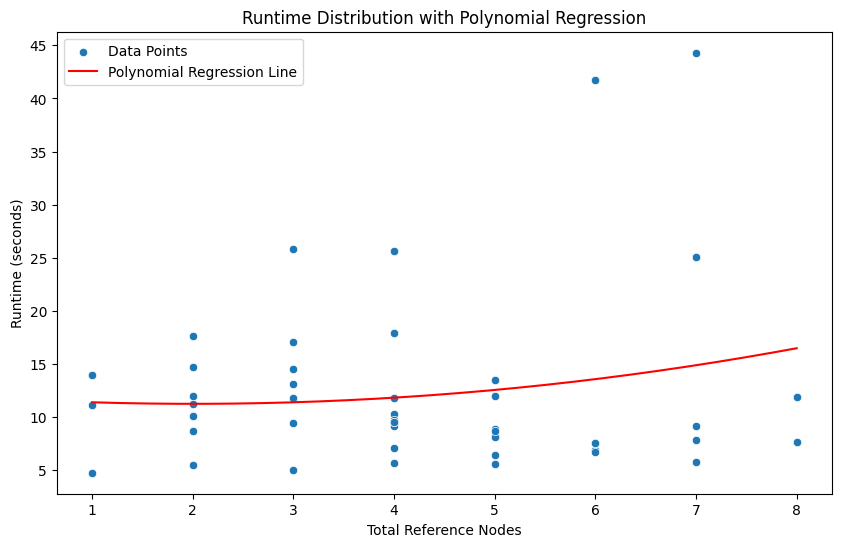

In [9]:
plot_runtime_distribution(result_df)